In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, os, json

In [2]:
file_path = "v1_LOD_ethylbenzene.xlsx"
df = pd.read_excel(file_path)
df.head()

,Timestamp,Time (s),ENS160_R0 (Ohm),ENS160_R1 (Ohm),ENS160_R2 (Ohm),ENS160_R3 (Ohm),SGP41_VOC_R (Ohm),SGP41_NOx_R (Ohm),TGS2602 (Ohm)
0,00:25:58.400000,0.0,111947,1,221858,44935,27539,0,460.12
1,00:25:59.400000,1.0,111568,1,226332,43720,27610,0,460.12
2,00:26:00.400000,2.0,112288,1,224273,43823,27661,0,460.12
3,00:26:01.400000,3.0,111116,1,223289,44859,27697,0,470.83
4,00:26:02.400000,4.0,111493,1,226026,45301,27719,0,460.12


In [3]:
# CLEAN
# rename columns
df = df.rename(columns={"Time (s)": "Time_s",
                        "ENS160_R0 (Ohm)": "ENS160_R0",
                        "ENS160_R1 (Ohm)": "ENS160_R1",
                        "ENS160_R2 (Ohm)": "ENS160_R2",
                        "ENS160_R3 (Ohm)": "ENS160_R3",
                        "SGP41_VOC_R (Ohm)": "SGP41_VOC_R",
                        "SGP41_NOx_R (Ohm)": "SGP41_NOx_R",
                        "TGS2602 (Ohm)": "TGS2602_R"
                       })

# change "-" to null
df = df.replace('-', np.nan)

# add time (min) column
i = df.columns.get_loc("Time_s") + 1
df.insert(i, "Time_min", df["Time_s"] / 60)

df.head(9)

,Timestamp,Time_s,Time_min,ENS160_R0,ENS160_R1,ENS160_R2,ENS160_R3,SGP41_VOC_R,SGP41_NOx_R,TGS2602_R
0,00:25:58.400000,0.0,0.000000,111947,1,221858,44935,27539,0,460.12
1,00:25:59.400000,1.0,0.016667,111568,1,226332,43720,27610,0,460.12
2,00:26:00.400000,2.0,0.033333,112288,1,224273,43823,27661,0,460.12
3,00:26:01.400000,3.0,0.050000,111116,1,223289,44859,27697,0,470.83
4,00:26:02.400000,4.0,0.066667,111493,1,226026,45301,27719,0,460.12
5,00:26:03.400000,5.0,0.083333,110554,1,218282,44076,27757,0,460.12
6,00:26:04.400000,6.0,0.100000,106046,1,204687,37303,27782,0,460.12
7,00:26:05.400000,7.0,0.116667,105259,1,197474,34358,27816,17752,438.78
8,00:26:06.400000,8.0,0.133333,NaN,NaN,NaN,NaN,27858,17648,449.44


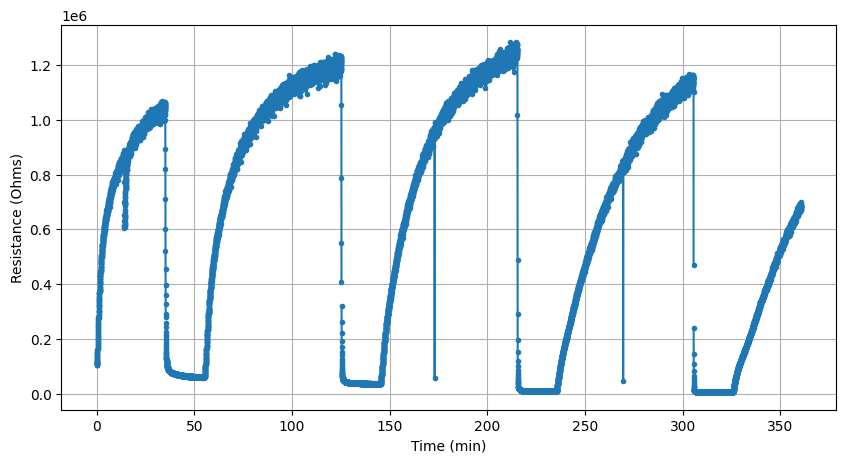

In [4]:
# plot resistances

# define segment
plot_df = df.iloc[:21600]

# plot
plt.figure(figsize=[10,5])
plt.plot(
    plot_df["Time_min"],
    plot_df["ENS160_R0"],
    marker="o",
    linestyle="-",
    markersize=3
)
#plt.title('ENS160 R0 Resistance Output to Ethylbenzene Dosing')
plt.xlabel('Time (min)')
plt.ylabel('Resistance (Ohms)')
plt.grid()
plt.show()

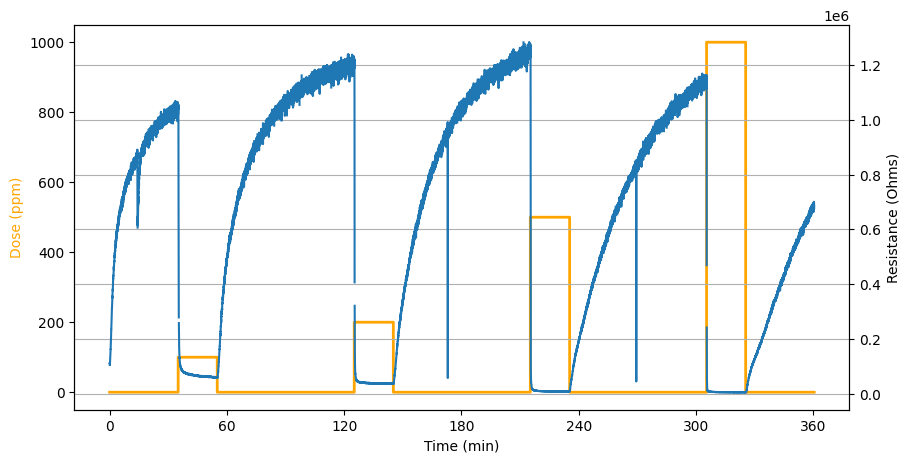

In [5]:
# define dosing profile
dosing = [0]*(35*60) + [100]*(20*60) + [0]*(70*60) + [200]*(20*60) + [0]*(70*60) + [500]*(20*60) + [0]*(70*60) + [1000]*(20*60)
left = len(plot_df) - len(dosing)
dosing = dosing + [0]*left
plot_df['dosing'] = dosing

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.step(plot_df["Time_min"], plot_df["dosing"], where="post", color="orange", linewidth=2)
ax1.set_ylabel("Dose (ppm)",  color="orange")
ax1.set_xlabel("Time (min)")
ax1.set_xticks(
    np.arange(
        0,
        plot_df["Time_min"].max() + 60,
        60
    )
)

ax2 = ax1.twinx()
ax2.plot(plot_df["Time_min"], plot_df["ENS160_R0"], markersize=3)
ax2.set_ylabel("Resistance (Ohms)")
ax2.grid()

plt.show()

In [6]:
# sensitivity calculation
res_cols = ["ENS160_R0", "ENS160_R1", "ENS160_R2", "ENS160_R3", "SGP41_VOC_R", "SGP41_NOx_R", "TGS2602_R"] #define all resistance columns

for col in res_cols:
    i = df.columns.get_loc(col) + 1
    r = df[col]
    r_max = df[col].max()
    s_col = col.replace("_R", "_S")

    r = df[col].replace(0, np.nan) # avoid divide by 0
    df.insert(i, s_col, np.where(r != 0, r_max / r - 1, np.nan))

In [7]:
df.head()

,Timestamp,Time_s,Time_min,ENS160_R0,ENS160_S0,ENS160_R1,ENS160_S1,ENS160_R2,ENS160_S2,ENS160_R3,ENS160_S3,SGP41_VOC_R,SGP41_VOC_S,SGP41_NOx_R,SGP41_NOx_S,TGS2602_R,TGS2602_S
0,00:25:58.400000,0.0,0.000000,111947,12.47259,1,0.0,221858,4.806205,44935,8.918148,27539,0.235811,0,NaN,460.12,7.723159
1,00:25:59.400000,1.0,0.016667,111568,12.518357,1,0.0,226332,4.691431,43720,9.193779,27610,0.232633,0,NaN,460.12,7.723159
2,00:26:00.400000,2.0,0.033333,112288,12.431676,1,0.0,224273,4.743683,43823,9.16982,27661,0.230360,0,NaN,460.12,7.723159
3,00:26:01.400000,3.0,0.050000,111116,12.573347,1,0.0,223289,4.768994,44859,8.934952,27697,0.228761,0,NaN,470.83,7.524733
4,00:26:02.400000,4.0,0.066667,111493,12.52745,1,0.0,226026,4.699136,45301,8.838017,27719,0.227786,0,NaN,460.12,7.723159


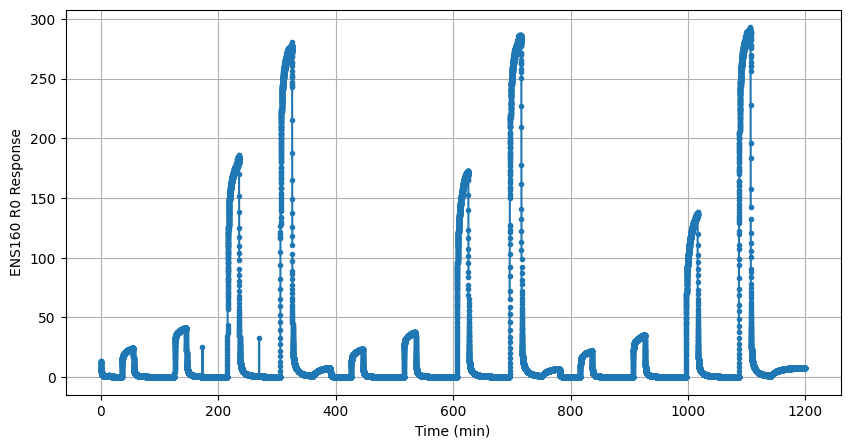

In [8]:
# plot sensitivities (response)
plt.figure(figsize=[10,5])
plt.plot(
    df["Time_min"],
    df["ENS160_S0"],
    marker="o",
    linestyle="-",
    markersize=3
)
#plt.title('ENS160 R0 Response to Ethylbenzene Dosing')
plt.xlabel('Time (min)')
plt.ylabel('ENS160 R0 Response')
plt.grid()
plt.show()

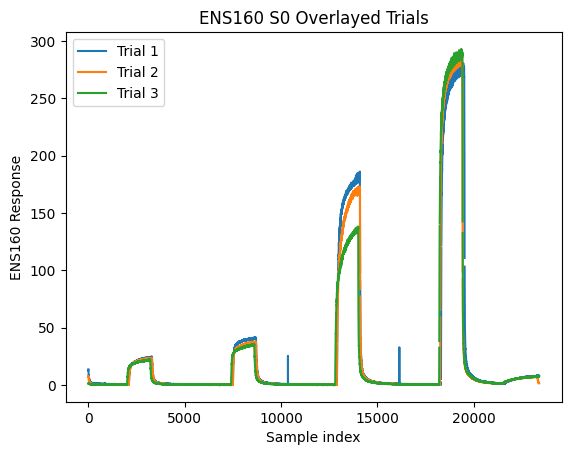

In [9]:
# check that trials are broken correctly
trial_len = 23400  # rows per trial

t1 = df.iloc[0 : trial_len]
t2 = df.iloc[trial_len : 2 * trial_len]
t3 = df.iloc[2 * trial_len : 3 * trial_len]

plt.figure()

plt.plot(
    t1.index - t1.index[0],
    t1["ENS160_S0"],
    label="Trial 1",
    markersize=2
)

plt.plot(
    t2.index - t2.index[0],
    t2["ENS160_S0"],
    label="Trial 2",
    markersize=2
)

plt.plot(
    t3.index - t3.index[0],
    t3["ENS160_S0"],
    label="Trial 3",
    markersize=2
)

plt.xlabel("Sample index")
plt.ylabel("ENS160 Response")
plt.title("ENS160 S0 Overlayed Trials")
plt.legend()
plt.show()


In [10]:
#RESHAPE BY ADDING TRIALS AS ANOTHER SET OF COLUMNS
# split trials by index
df_t1 = df.iloc[0 : trial_len].copy()
df_t2 = df.iloc[trial_len : 2 * trial_len].copy()
df_t3 = df.iloc[2 * trial_len : 3 * trial_len].copy()

# reset indices so rows align
df_t1.reset_index(drop=True, inplace=True)
df_t2.reset_index(drop=True, inplace=True)
df_t3.reset_index(drop=True, inplace=True)

# rename columns for t2 and t3
df_t1.columns = [f"{c}_t1" for c in df_t1.columns]
df_t2.columns = [f"{c}_t2" for c in df_t2.columns]
df_t3.columns = [f"{c}_t3" for c in df_t3.columns]

# concatenate column-wise
trial_df = pd.concat([df_t1, df_t2, df_t3], axis=1)

keep_mask = (
    ~trial_df.columns.str.contains("_R") &
    ~trial_df.columns.str.contains("Timestamp") &
    ~trial_df.columns.str.contains("Time_min") &
    (
        ~trial_df.columns.str.contains("Time_s") |
        trial_df.columns.str.endswith("_t1")
    )
)

trial_df = trial_df.loc[:, keep_mask].copy()

In [11]:
trial_df

,Time_s_t1,ENS160_S0_t1,ENS160_S1_t1,ENS160_S2_t1,ENS160_S3_t1,SGP41_VOC_S_t1,SGP41_NOx_S_t1,TGS2602_S_t1,ENS160_S0_t2,ENS160_S1_t2,...,SGP41_VOC_S_t2,SGP41_NOx_S_t2,TGS2602_S_t2,ENS160_S0_t3,ENS160_S1_t3,ENS160_S2_t3,ENS160_S3_t3,SGP41_VOC_S_t3,SGP41_NOx_S_t3,TGS2602_S_t3
0,0.00,12.47259,0.0,4.806205,8.918148,0.235811,NaN,7.723159,7.638864,0.0,...,0.233840,0.184019,7.524733,NaN,NaN,NaN,NaN,0.155894,0.175240,2.138302
1,1.00,12.518357,0.0,4.691431,9.193779,0.232633,NaN,7.723159,7.851968,0.0,...,0.232946,0.184177,7.334787,1.384056,0.0,4.821976,1.827473,0.155110,0.174851,2.108046
2,2.00,12.431676,0.0,4.743683,9.16982,0.230360,NaN,7.723159,7.851968,0.0,...,0.233214,0.184019,7.524733,1.343257,0.0,4.778777,1.723224,0.153700,0.175396,2.108046
3,3.00,12.573347,0.0,4.768994,8.934952,0.228761,NaN,7.524733,7.80417,0.0,...,0.233750,0.183467,7.334787,1.342463,0.0,4.788567,1.730616,0.152723,0.173996,2.108046
4,4.00,12.52745,0.0,4.699136,8.838017,0.227786,NaN,7.723159,7.750688,0.0,...,0.233303,0.183940,7.524733,1.32194,0.0,4.804269,1.777205,0.152138,0.174929,2.078298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23395,23427.78,7.836979,0.0,8.555606,11.480663,0.233348,0.183624,7.334787,1.490449,0.0,...,0.160506,0.175863,2.26471,7.300629,0.0,16.975649,13.401603,0.256572,0.176408,8.374737
23396,23428.78,7.777373,0.0,8.633571,11.36295,0.233080,0.183940,7.524733,1.410831,0.0,...,0.159794,0.175785,2.232267,7.314723,0.0,16.800036,13.188857,0.256943,0.177032,7.930447
23397,23429.78,7.735887,0.0,8.604266,11.258891,0.233616,0.183546,7.334787,1.453636,0.0,...,0.158412,0.175396,2.26471,7.175188,0.0,16.830341,13.622744,0.256572,0.176408,8.147409
23398,23430.78,7.810136,0.0,8.649881,11.40079,0.233393,0.183861,7.334787,1.376,0.0,...,0.157309,0.175162,2.200386,7.289452,0.0,17.220759,13.236903,0.257268,0.176642,8.147409


In [12]:
# calculate means and sds
s_cols = ["ENS160_S0", "ENS160_S1", "ENS160_S2", "ENS160_S3", "SGP41_VOC_S", "SGP41_NOx_S", "TGS2602_S"] #define all resistance columns

calc_df = pd.DataFrame()
calc_df["Time_s"] = trial_df["Time_s_t1"]

for s in s_cols:
    trial_cols = [f"{s}_t1", f"{s}_t2", f"{s}_t3"]

    calc_df[f"{s}_mean"] = trial_df[trial_cols].mean(axis=1)
    calc_df[f"{s}_std"]  = trial_df[trial_cols].std(axis=1)


In [13]:
calc_df

,Time_s,ENS160_S0_mean,ENS160_S0_std,ENS160_S1_mean,ENS160_S1_std,ENS160_S2_mean,ENS160_S2_std,ENS160_S3_mean,ENS160_S3_std,SGP41_VOC_S_mean,SGP41_VOC_S_std,SGP41_NOx_S_mean,SGP41_NOx_S_std,TGS2602_S_mean,TGS2602_S_std
0,0.00,10.055727,3.417961,0.0,0.0,6.6874,2.660412,10.16154,1.758422,0.208515,0.045581,0.179630,0.006208,5.795398,3.168692
1,1.00,7.25146,5.591388,0.0,0.0,6.004727,2.162625,7.40458,4.93222,0.206896,0.044849,0.179514,0.006595,5.721997,3.135792
2,2.00,7.208967,5.572104,0.0,0.0,6.049827,2.231984,7.52178,5.175233,0.205758,0.045106,0.179707,0.006098,5.785313,3.186151
3,3.00,7.239993,5.636658,0.0,0.0,6.000223,2.115622,7.384875,5.060518,0.205078,0.045409,0.178732,0.006696,5.655855,3.07396
4,4.00,7.200026,5.623014,0.0,0.0,5.986445,2.139283,7.295534,4.931458,0.204409,0.045352,0.179435,0.006372,5.775397,3.203318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23395,23427.78,5.542686,3.519571,0.0,0.0,10.18863,6.135718,8.920633,6.172866,0.216809,0.050123,0.178632,0.004332,5.991411,3.269037
23396,23428.78,5.500976,3.549715,0.0,0.0,10.085844,6.118712,8.820931,6.053428,0.216606,0.050626,0.178919,0.004393,5.895816,3.179205
23397,23429.78,5.454904,3.476522,0.0,0.0,10.108649,6.110018,8.921397,6.209341,0.216200,0.051345,0.178450,0.004442,5.915635,3.187794
23398,23430.78,5.491863,3.573936,0.0,0.0,10.301758,6.258749,8.821722,6.126374,0.215990,0.052202,0.178555,0.004654,5.894194,3.224632


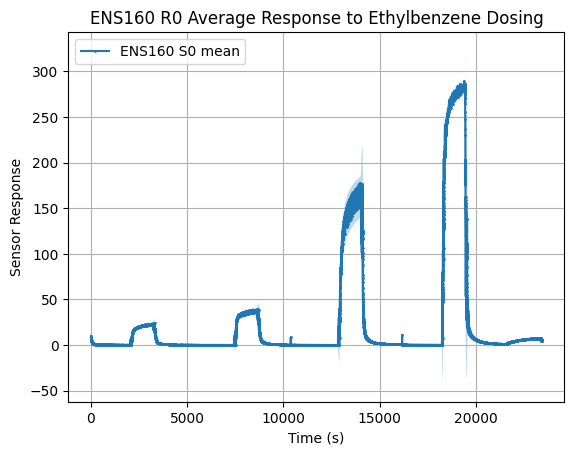

In [14]:
time = calc_df["Time_s"].astype(float).to_numpy()
avg = calc_df["ENS160_S0_mean"].astype(float).to_numpy()
std = calc_df["ENS160_S0_std"].astype(float).to_numpy()

mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
time, avg, std = time[mask], avg[mask], std[mask]

line, = plt.plot(
    time,
    avg,
    label="ENS160 S0 mean",
    marker="o",
    markersize=1,
    linestyle="-"
)

plt.fill_between(
    time,
    avg - std,
    avg + std,
    alpha=0.3
)

plt.xlabel("Time (s)")
plt.ylabel("Sensor Response")
plt.title("ENS160 R0 Average Response to Ethylbenzene Dosing")
plt.legend()
plt.grid()
plt.show()

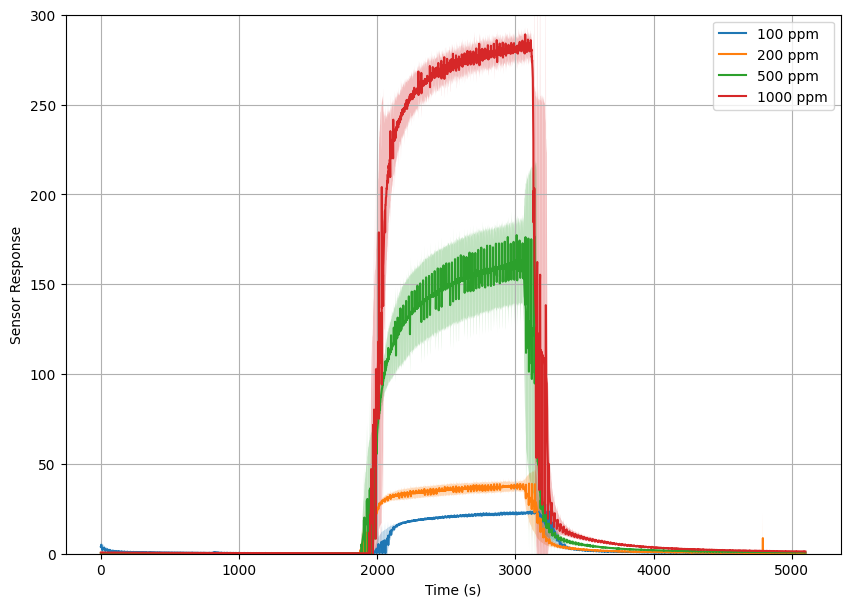

In [15]:
time = calc_df["Time_s"].astype(float).to_numpy()
avg = calc_df["ENS160_S0_mean"].astype(float).to_numpy()
std = calc_df["ENS160_S0_std"].astype(float).to_numpy()

mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
time, avg, std = time[mask], avg[mask], std[mask]

onsets = [2040, 7500, 12840, 18130]
pre = 2000
post = 3100

labels = ["100 ppm", "200 ppm", "500 ppm", "1000 ppm"]
dt = 1 #s

plt.figure(figsize=[10,7])

for i, onset in enumerate(onsets):
    start = onset - pre
    end   = onset + post

    if start < 0 or end > len(avg):
        print(f"Skipping segment {i+1}: out of bounds")
        continue

    a = avg[start:end]
    s = std[start:end]
    t = np.arange(0, pre+post) * dt


    plt.plot(t, a, label=labels[i])
    plt.fill_between(t, a - s, a + s, alpha=0.3)

plt.xlabel("Time (s)")
plt.ylabel("Sensor Response")
#plt.title("ENS160 R0 Response to Ethylbenzene Dosing")
#plt.xlim([1500,4000])
plt.ylim([0,300])
plt.legend()
plt.grid()
plt.show()


In [18]:
avg

array([10.05572665,  7.25146025,  7.20896673, ...,  5.4549041 ,
        5.49186264,  5.48132004], shape=(23233,))

Baseline σ: 0.3012
3σ noise: 0.9036
Slope (m): 0.2914 response/ppm
Estimated LOD: 3.10 ppm
[ 24.96514856  39.34823232 167.57753275 305.81583738]
SNR at 100 ppm: 27.95
SNR at 200 ppm: 31.90
SNR at 500 ppm: 44.48
SNR at 1000 ppm: 49.71


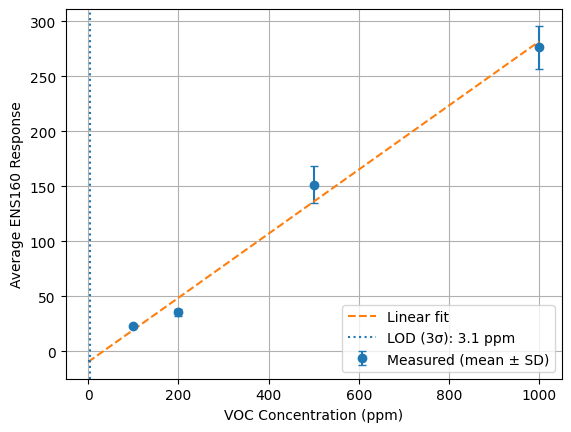

In [16]:
concs = [100, 200, 500, 1000] # ppm
onsets = [2040, 7500, 12840, 18130]

# define baseline window
baseline_end = onsets[0] - 1
baseline_start = max(0, baseline_end - 600)  # 10 min
baseline_region = avg[baseline_start:baseline_end]

# calculate baseline noise (sigma)
sigma = np.nanstd(baseline_region, ddof=1)
noise_3sigma = 3 * sigma

# compute response from end of dosing window
pre = 900 # 15 min into dosing
post = 1140 # 19 min into dosing
avg_responses = []
err_responses = []
for onset in onsets:
    start = onset + pre
    end   = onset + post

    #find mean and SD of segment
    seg = avg[start:end]
    avg_responses.append(np.nanmean(avg[start:end]))
    err_responses.append(np.nanstd(seg, ddof=1))

# fit calibration curve
m, b = np.polyfit(concs, avg_responses, 1)  # response = m * C + b

LOD_ppm = noise_3sigma / m  # LOD = 3σ / slope
print(f"Baseline σ: {sigma:.4g}")
print(f"3σ noise: {noise_3sigma:.4g}")
print(f"Slope (m): {m:.4g} response/ppm")
print(f"Estimated LOD: {LOD_ppm:.2f} ppm")

snr = avg_responses / noise_3sigma
print(snr)
snr = 20 * np.log10(snr)
for c, s in zip(concs, snr):
    print(f"SNR at {c:.0f} ppm: {s:.2f}")

plt.figure()
# points + error bars
plt.errorbar(
    concs, avg_responses,
    yerr=err_responses,
    fmt="o",
    capsize=3,
    label="Measured (mean ± SD)"
)

# fit line, extend to LOD
x_end = max(concs[-1], LOD_ppm)
xfit = np.linspace(0, x_end, 200)
yfit = m * xfit + b
plt.plot(xfit, yfit, linestyle="--", label="Linear fit")

# LOD marker
plt.axvline(LOD_ppm, linestyle=":", label=f"LOD (3σ): {LOD_ppm:.1f} ppm")

# horizontal line at the response level where the fit hits LOD
y_at_LOD = m * LOD_ppm + b
plt.hlines(
    y=y_at_LOD,
    xmin=0,
    xmax=LOD_ppm,
)

plt.xlabel("VOC Concentration (ppm)")
plt.ylabel("Average ENS160 Response")
#plt.title("ENS160 R0 Steady-State Response to Ethylbenzene")
plt.grid()
plt.legend()
plt.show()

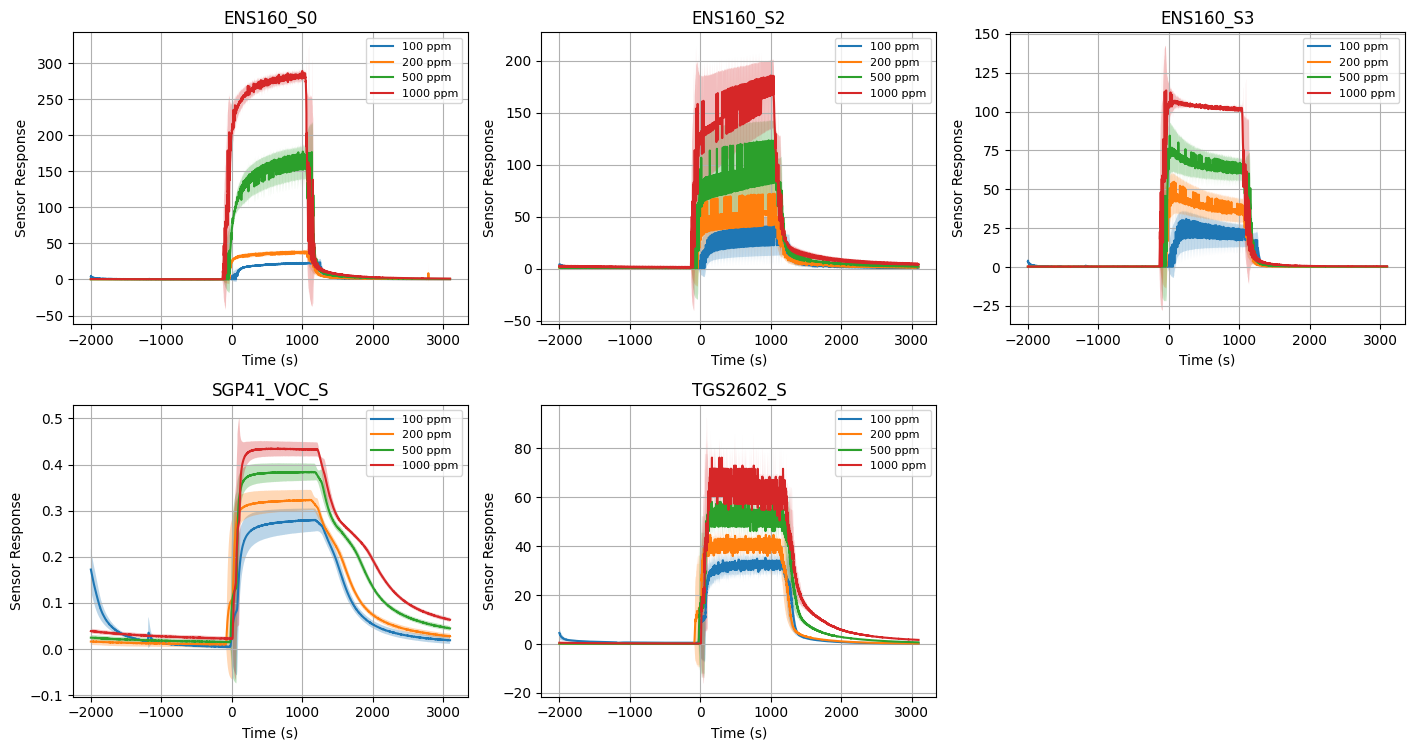

In [21]:
# PLOTS FOR ALL SENSORS
# drop
#calc_df = calc_df.drop(columns=['ENS160_S1_mean','ENS160_S1_std', 'SGP41_NOx_S_mean', 'SGP41_NOx_S_std'])

onsets = [2040, 7500, 12840, 18200]
pre = 2000
post = 3100
labels = ["100 ppm", "200 ppm", "500 ppm", "1000 ppm"]
dt = 1  # s

# extract column names
cols = list(calc_df.columns)
time_col = cols[0]
sensor_cols = cols[1:] # mean & std pairs
n_sensors = len(sensor_cols) // 2

ncols = 3
nrows = int(np.ceil(n_sensors / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4*nrows)
)

axes = axes.flatten()

# loop through sensors
for i in range(n_sensors):
    ax = axes[i]

    mean_col = sensor_cols[2*i]
    std_col  = sensor_cols[2*i + 1]

    time = calc_df[time_col].astype(float).to_numpy()
    avg  = calc_df[mean_col].astype(float).to_numpy()
    std  = calc_df[std_col].astype(float).to_numpy()

    mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
    avg, std = avg[mask], std[mask]

    for j, onset in enumerate(onsets):
        start = onset - pre
        end   = onset + post

        if start < 0 or end > len(avg):
            continue

        a = avg[start:end]
        s = std[start:end]
        t = np.arange(-pre, post) * dt

        n = min(len(t), len(a), len(s))
        ax.plot(t[:n], a[:n], label=labels[j])
        ax.fill_between(
            t[:n],
            (a - s)[:n],
            (a + s)[:n],
            alpha=0.3
        )

    ax.set_title(mean_col.replace("_mean", ""))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Sensor Response")
    ax.grid(True)
    ax.legend(fontsize=8)

#hide unused subplots
for ax in axes[n_sensors:]:
    ax.axis("off")

#fig.suptitle("Sensor Responses to Ethylbenzene Dosing", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

In [22]:
voc_name = "ethylbenzene"

calc_df.to_csv(f"{voc_name}_clean.csv", index=False)

meta = {
    "voc_name": "Ethylbenzene",
    "unit": "ppm",
    "onsets": [2040, 7500, 12840, 18200],
    "labels": ["100 ppm", "200 ppm", "500 ppm", "1000 ppm"],
    "pre": 2000,
    "post": 3100,
    "dt": 1
}

with open(f"{voc_name}_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

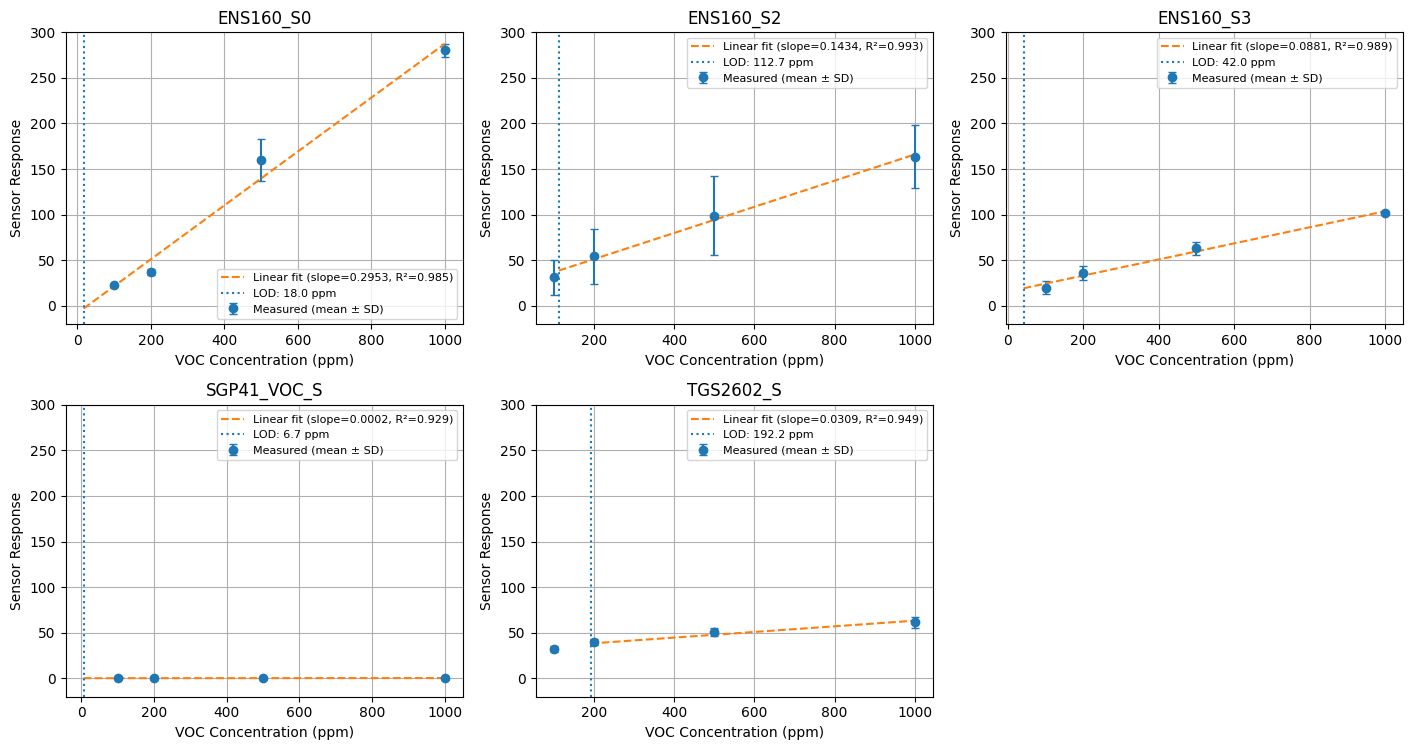

        Sensor   Slope      R2   LOD_ppm      SNR
0    ENS160_S0  0.2953  0.9848   18.0382  36.9374
1    ENS160_S2  0.1434  0.9929  112.6934  24.1743
2    ENS160_S3  0.0881  0.9887   41.9738  33.0464
3  SGP41_VOC_S  0.0002  0.9285    6.7215  59.8075
4    TGS2602_S  0.0309  0.9491  192.1658  27.3755


In [36]:
# drop
#calc_df = calc_df.drop(columns=['ENS160_S1_mean','ENS160_S1_std', 'SGP41_NOx_S_mean', 'SGP41_NOx_S_std'])

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4*nrows),
)

axes = axes.flatten()
results = []

# loop through sensors
for i in range(n_sensors):
    ax = axes[i]

    mean_col = sensor_cols[2*i]
    std_col  = sensor_cols[2*i + 1]

    # compute response from end of dosing window
    pre = 900 # 15 min into dosing
    post = 1140 # 19 min into dosing
    avg_responses = []
    err_responses = []
    noises = []
    
    mean_data = calc_df[mean_col].values
    std_data  = calc_df[std_col].values

    # compute points + error bars + signal noise
    for onset in onsets:
        start = onset + pre
        end   = onset + post
        #find mean and SD of segment
        segment_mean = mean_data[start:end]
        segment_std  = std_data[start:end]
        avg_responses.append(np.nanmean(segment_mean))
        err_responses.append(np.sqrt(np.nanmean(segment_std**2)))
        # signal noise
        noises.append(np.nanstd(mean_data[start:end], ddof=1))
    
    # fit calibration curve
    m, b = np.polyfit(concs, avg_responses, 1)  # response = m * C + b

    # predictions and R^2
    avg_responses = np.array(avg_responses, dtype=float)
    #noises = np.array(noises, dtype=float)
    yhat = m * np.array(concs) + b
    ss_res = np.nansum((avg_responses - yhat)**2)
    ss_tot = np.nansum((avg_responses - np.nanmean(avg_responses))**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    # single noise estimate for this sensor
    sigma_mean = np.nanmean(noises)

    # LOD using simplified IUPAC formula
    LOD_ppm = (3 * sigma_mean) / abs(m)

    # SNR
    noise_mean = np.nanmean(noises)
    mean_response = np.nanmean(avg_responses)
    snr = mean_response / noise_mean
    snr_db = 20 * np.log10(snr)

    # points + errorbars
    ax.errorbar(
        concs, avg_responses,
        yerr=err_responses,
        fmt="o",
        capsize=3,
        label="Measured (mean ± SD)"
    )
    # fit line, extend to LOD
    x_end   = max(concs)
    xfit = np.linspace(LOD_ppm, x_end, 200)
    yfit = m * xfit + b
    ax.plot(xfit, yfit, linestyle="--", label=f"Linear fit (slope={m:.4f}, R²={R2:.3f})")

    # LOD marker
    ax.axvline(LOD_ppm, linestyle=":", label=f"LOD: {LOD_ppm:.1f} ppm")

    ax.set_title(mean_col.replace("_mean", ""))
    ax.set_xlabel("VOC Concentration (ppm)")
    ax.set_ylabel("Sensor Response")
    ax.set_ylim(-20,300)
    ax.grid(True)
    ax.legend(fontsize=8)

    # add to results
    sensor_name = mean_col.replace("_mean", "")
    results.append({
        "Sensor": sensor_name,
        "Slope": m,
        "R2": R2,
        "LOD_ppm": LOD_ppm,
        "SNR": snr_db
    })
    
#hide unused subplots
for ax in axes[n_sensors:]:
    ax.axis("off")
    
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

results_df = pd.DataFrame(results)
print(results_df.round(4))